# **Point Net - Classification**

In [1]:
import os
import re
from glob import glob
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
from torchmetrics.classification import MulticlassMatthewsCorrCoef
import open3d as o3

from open3d.web_visualizer import draw # for non Colab
import os, os.path as osp

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.


## Now: feature extraction of the foils

In [2]:
import torch
import os, os.path as osp
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

In [3]:
'''    
# ------------------------------------------------------------------------------- t-SNE on raw (x,y) coordinates — no preprocessing
from torch.utils.data import DataLoader
from utils.shapenet_dataset import ShapenetDataset    
from sklearn.manifold import TSNE
ROOT = osp.abspath("shapenet_like_out")
npoints = 10000
BATCH_SIZE = 32
test_dataset = ShapenetDataset(ROOT, npoints=npoints, split='test', classification=True, normalize=False) #already normalized in convert_to_shapenet_like, see later if we keep it like that or not
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)    

N = len(test_dataset)
NPTS = getattr(test_dataset, "npoints", None)

# Build raw feature matrix by simple flattening of (x,y)
raw_xy = np.empty((N, 2 * NPTS), dtype=np.float32)
for i in range(N):
    pts, _ = test_dataset[i]                  # (NPTS, 3) tensor
    pts = np.asarray(pts)
    xy = pts[:, :2].reshape(-1)               # (2*NPTS,)
    raw_xy[i] = xy

tsne_raw = TSNE(
    n_components=2,
    metric='cosine',
    init='pca', # t is highly recommended to use another dimensionality reduction method (e.g. PCA for dense data or TruncatedSVD for sparse data)
    learning_rate='auto',
    perplexity=30, #  Consider selecting a value between 5 and 50
    verbose=1
)
X2_raw = tsne_raw.fit_transform(raw_xy)
print(f"[Raw (x,y) t-SNE computed: X2_raw={X2_raw.shape}")

# Plot (neutral)
plt.figure(figsize=(8, 6))
plt.scatter(X2_raw[:, 0], X2_raw[:, 1], s=7, color=(0.6, 0.6, 0.6), edgecolors='none')
plt.title(f'Raw geometry t-SNE (flattened x,y)')
plt.tight_layout()
plt.show()
'''

'    \n# ------------------------------------------------------------------------------- t-SNE on raw (x,y) coordinates — no preprocessing\nfrom torch.utils.data import DataLoader\nfrom utils.shapenet_dataset import ShapenetDataset    \nfrom sklearn.manifold import TSNE\nROOT = osp.abspath("shapenet_like_out")\nnpoints = 10000\nBATCH_SIZE = 32\ntest_dataset = ShapenetDataset(ROOT, npoints=npoints, split=\'test\', classification=True, normalize=False) #already normalized in convert_to_shapenet_like, see later if we keep it like that or not\ntest_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)    \n\nN = len(test_dataset)\nNPTS = getattr(test_dataset, "npoints", None)\n\n# Build raw feature matrix by simple flattening of (x,y)\nraw_xy = np.empty((N, 2 * NPTS), dtype=np.float32)\nfor i in range(N):\n    pts, _ = test_dataset[i]                  # (NPTS, 3) tensor\n    pts = np.asarray(pts)\n    xy = pts[:, :2].reshape(-1)               # (2*NPTS,)\n    raw_xy[i] = xy\n\ntsne_

2025-11-03 19:18:03,085 - Point_MAE - INFO - [Point_MAE] 
2025-11-03 19:18:03,086 - Transformer - INFO - [args] namespace(mask_ratio=0.6, mask_type='rand', trans_dim=384, encoder_dims=384, depth=12, drop_path_rate=0.1, num_heads=6, decoder_depth=4, decoder_num_heads=6)
2025-11-03 19:18:03,288 - Point_MAE - INFO - [Point_MAE] divide point cloud into G64 x S32 points ...


[load] missing=207 unexpected=5
[PointMAE] effective mask_ratio: 0.0
[PointMAE-pretrain] features: (1000, 384), labels: (1000,)
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.001s...
[t-SNE] Computed neighbors for 1000 samples in 0.010s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 0.002417
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.429298
[t-SNE] KL divergence after 1000 iterations: 0.581056
[PointMAE_pretrain] t-SNE computed: X2=(1000, 2)
[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\PointMAE_pretrain\PointMAE_pretrain_tsne_embeddings.png
[save] PointMAE_pretrain_tsne_embeddings.npy → c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\PointMAE_pretrain\PointMAE_pretrain_tsne_em

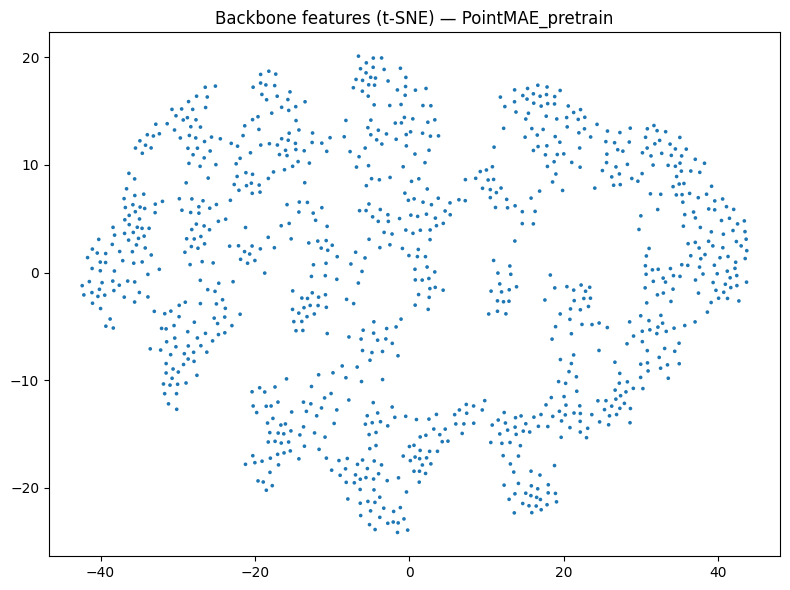

[PointMAE_pretrain] DBSCAN: clusters=8, noise=2 (eps=3.0, min_samples=10)
[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\PointMAE_pretrain\PointMAE_pretrain_tsne_dbscan.png


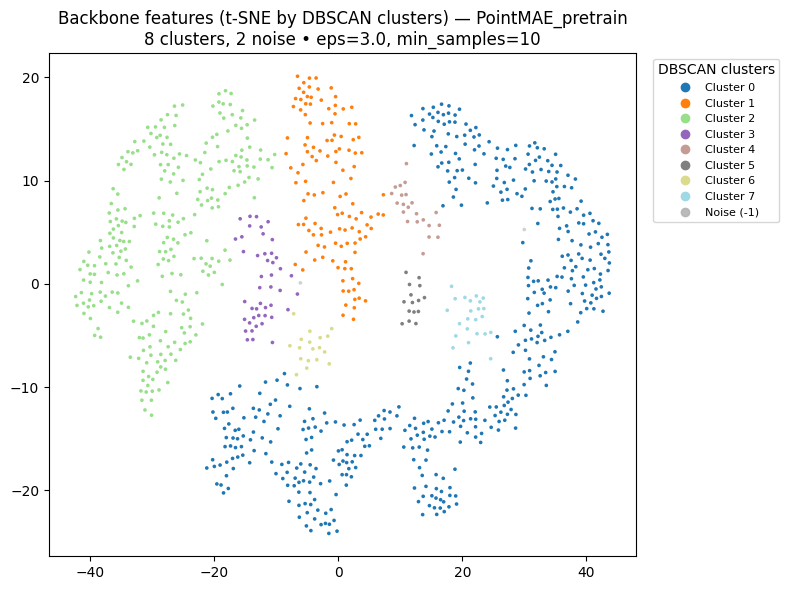

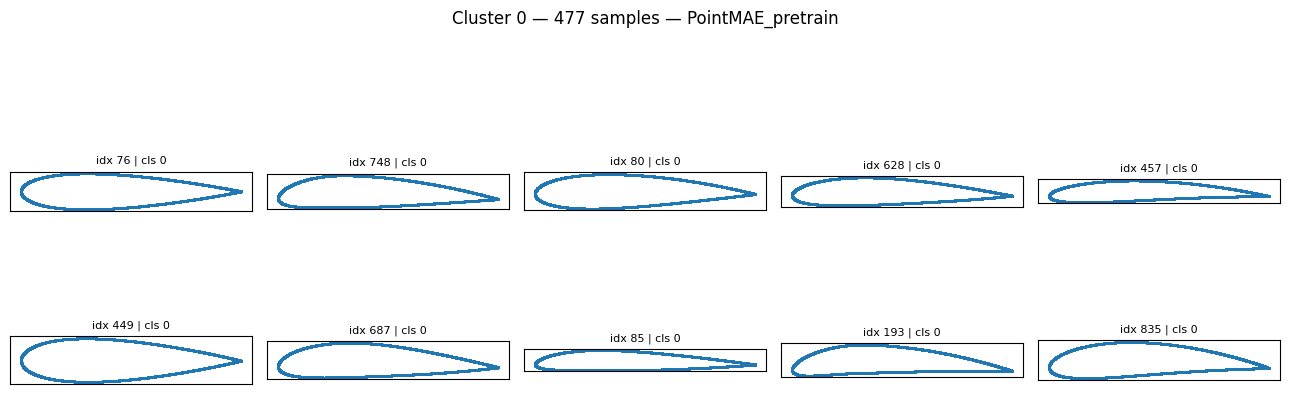

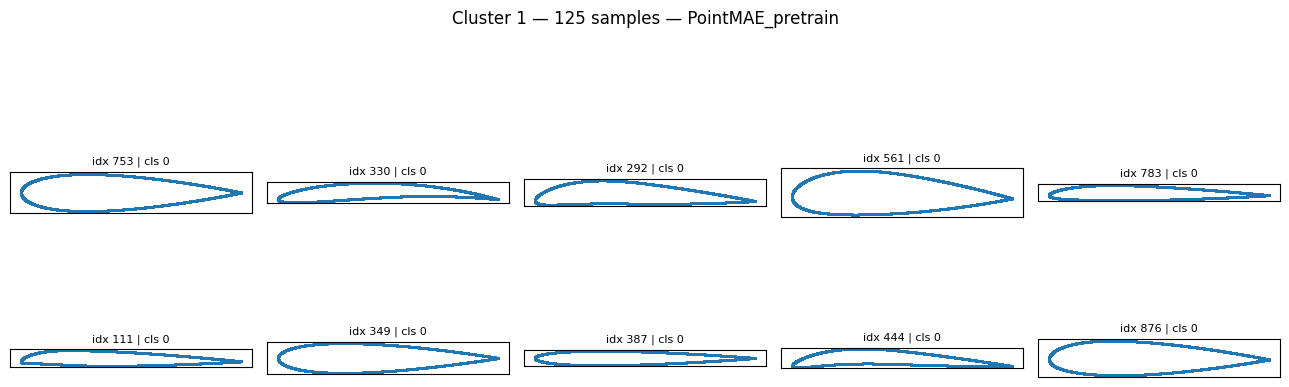

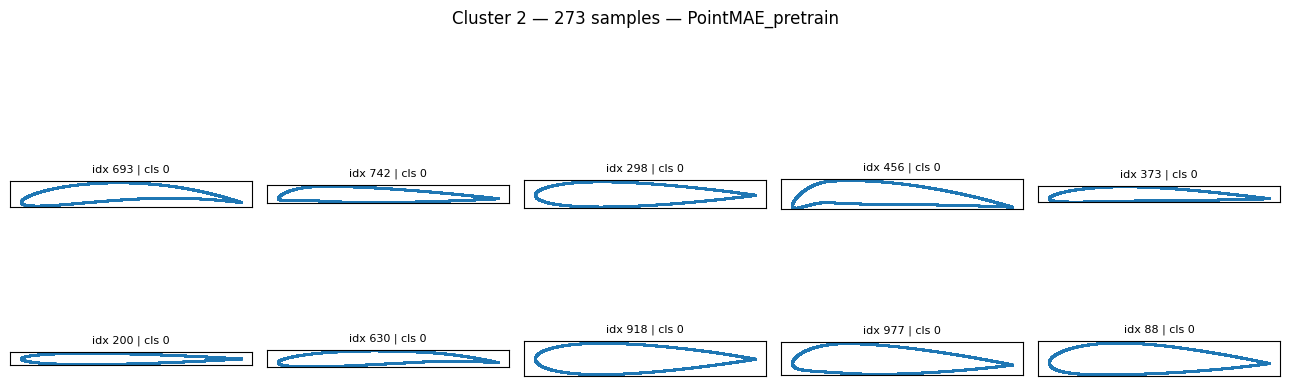

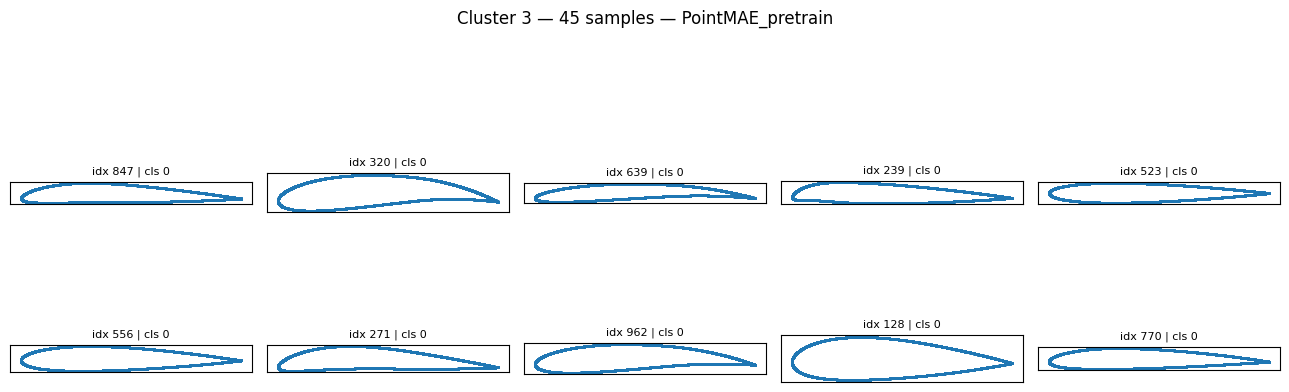

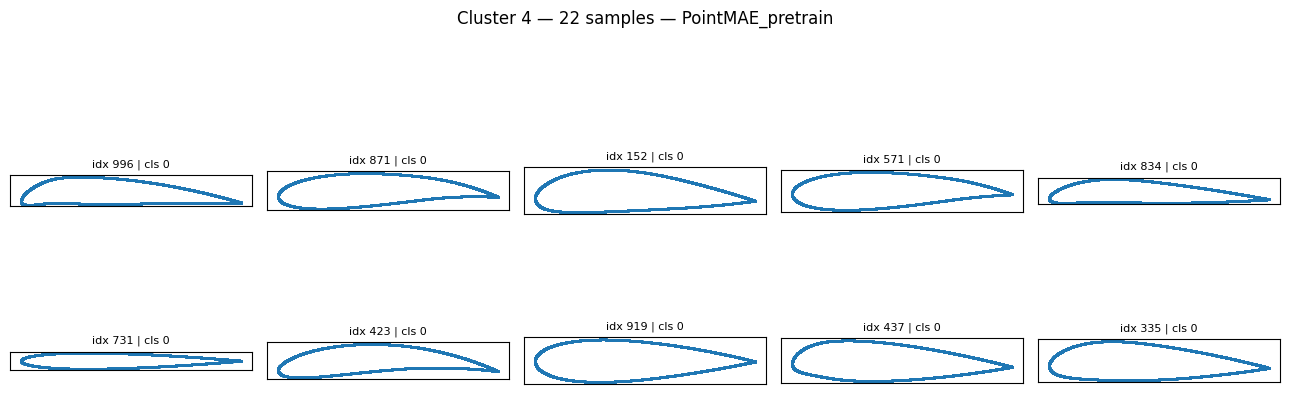

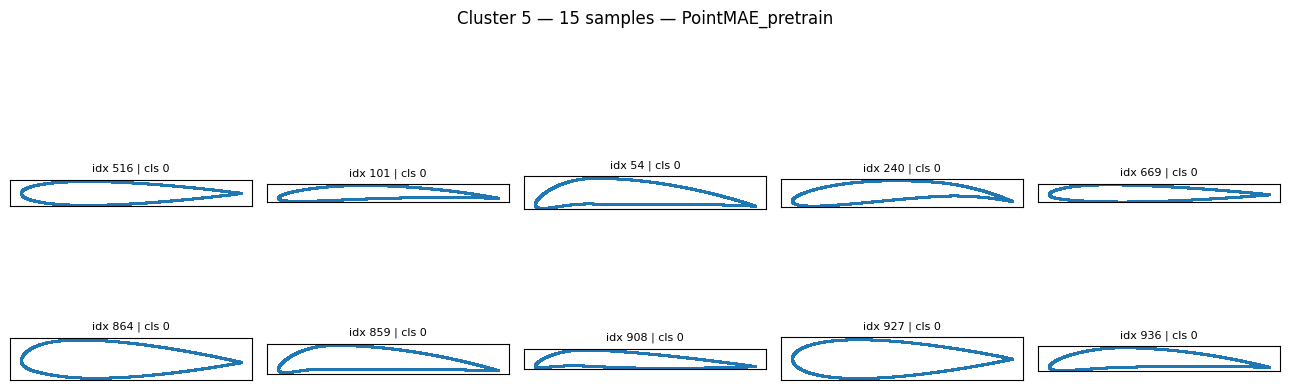

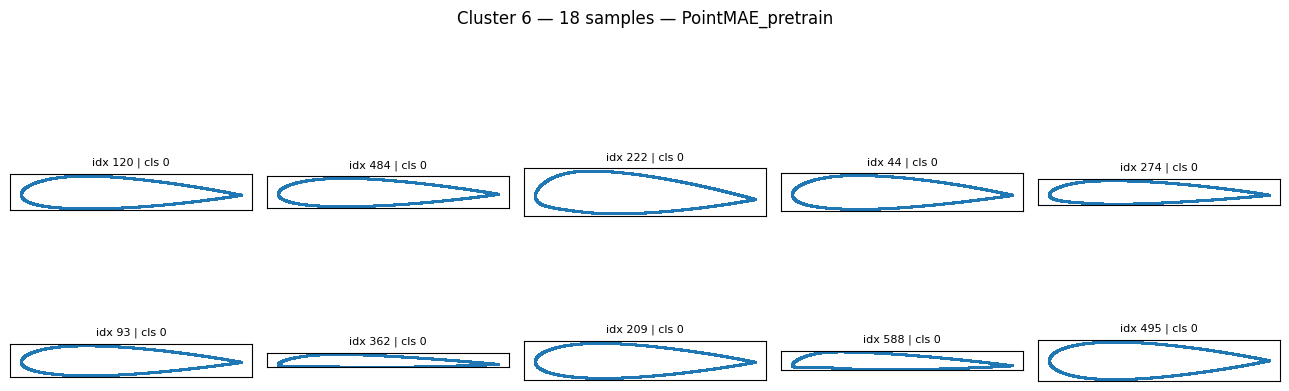

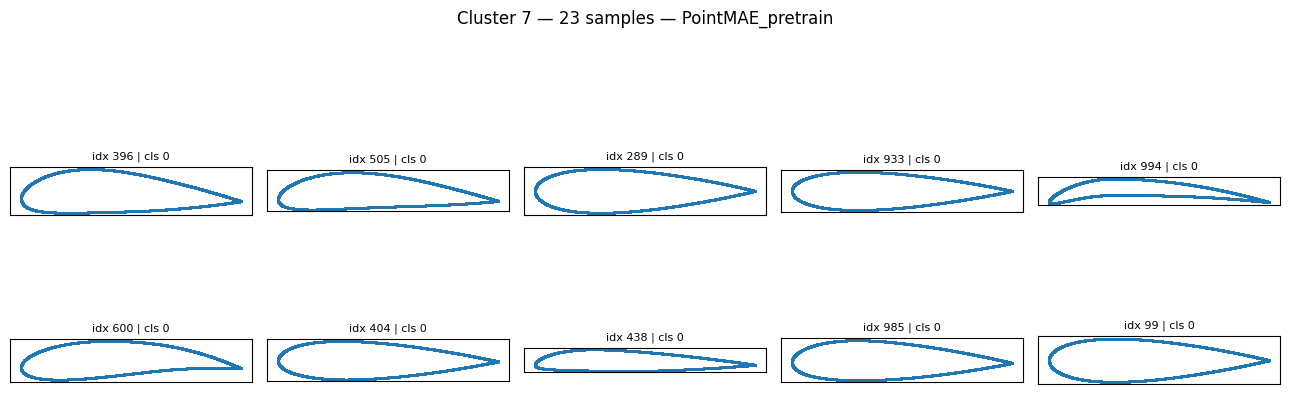

[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\PointMAE_pretrain\PointMAE_pretrain_tsne_area.png


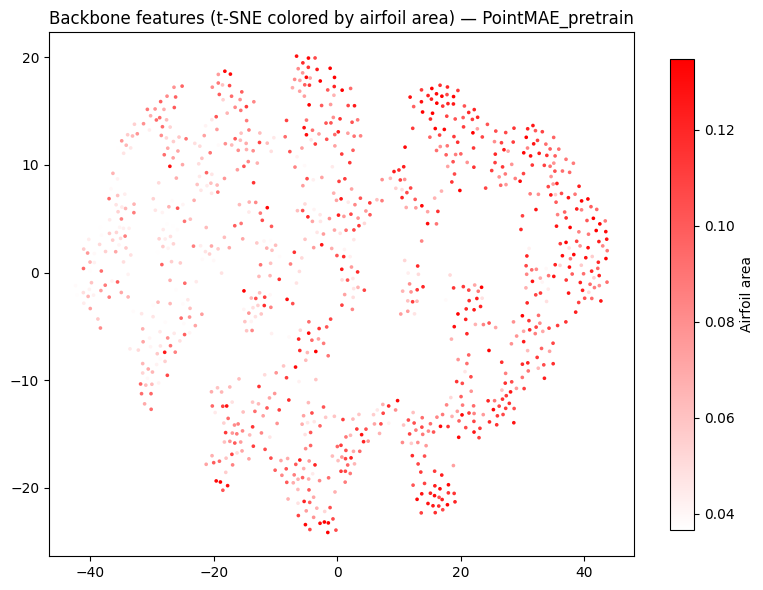

[PointMAE_pretrain] NACA kinds — 4-digit: 489, 5-digit: 511, unknown: 0
[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\PointMAE_pretrain\PointMAE_pretrain_tsne_camber.png


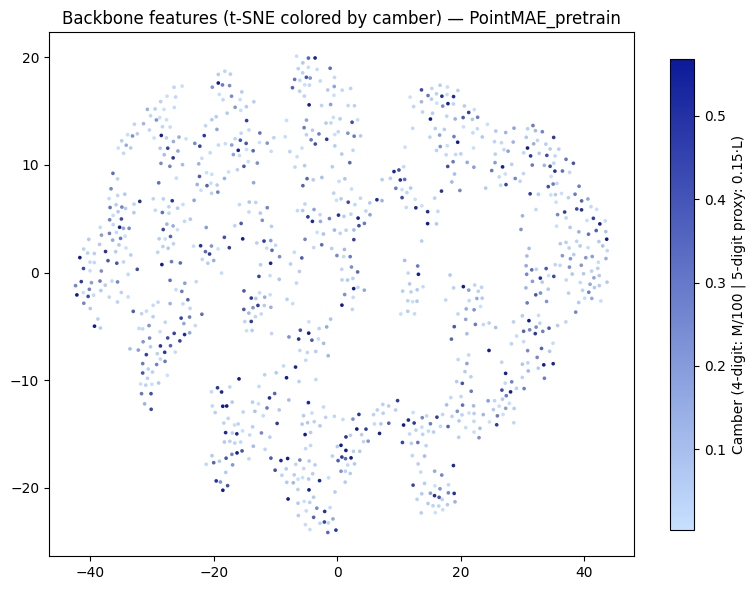

[plot] saved c:\Users\romai\OneDrive\Bureau\EPFL\MA3\Project\3DFundation4SurogateModeling\3DFundation4SurogateModeling2\point_netANDpoint_MAE\extracted_features\PointMAE_pretrain\PointMAE_pretrain_tsne_thickness.png


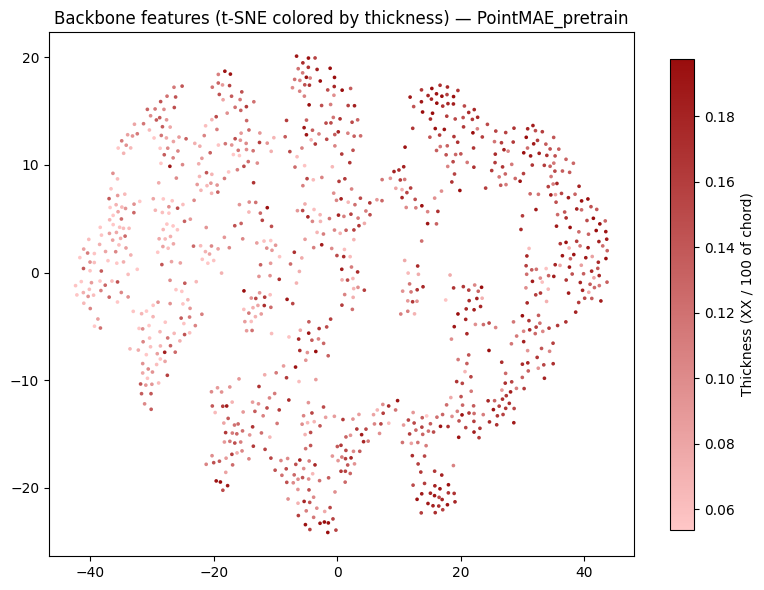

In [4]:
from models.point_mae.analyse_pointMAE_backbone import analyse_pointMAE_backbone
out_finetune = analyse_pointMAE_backbone(
    device=torch.device("cuda:0"),
    plots=True,
    npoints=10000
)